## Random Forest Model on Personal Transaction Data
#### Aleksa Marie Ocampo
#### CS 549 Machine Learning Spring 2026

### Loading Data

In [30]:
# data loading script with test splits
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape) 
print("features:", len(feature_cols))
print("classes:", y_train.nunique())
print(y_train.value_counts())

train: (8644, 12) (8644,)
test:  (2162, 12) (2162,)
features: 12
classes: 5
Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64


### Baseline Model

#### Importing the Model

In [31]:
# BASELINE MODEL:
# import random forest model
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#### Training the Model

In [32]:
# training the model and making predictions
depth_values = [None, 10, 20, 30]

baseline_cv_acc = []
baseline_cv_f1 = []

for depth in depth_values:
    print(f"Training baseline RF with max_depth = {depth}")

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        random_state=42
    )

    acc_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring="accuracy")
    f1_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring="f1_weighted")

    baseline_cv_acc.append(acc_scores.mean())
    baseline_cv_f1.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

Training baseline RF with max_depth = None
CV Acc: 0.3555, CV F1: 0.3437
--------------------------------------------------
Training baseline RF with max_depth = 10
CV Acc: 0.3895, CV F1: 0.3407
--------------------------------------------------
Training baseline RF with max_depth = 20
CV Acc: 0.3665, CV F1: 0.3457
--------------------------------------------------
Training baseline RF with max_depth = 30
CV Acc: 0.3557, CV F1: 0.3431
--------------------------------------------------


In [33]:
best_index = np.argmax(baseline_cv_f1)
best_depth = depth_values[best_index]

print("Best baseline depth:", best_depth)
print("Best baseline CV F1:", baseline_cv_f1[best_index])

Best baseline depth: 20
Best baseline CV F1: 0.3457083660402296


#### Baseline Evaluation

In [34]:
# BASELINE EVALUATION
# evaluate performance
base_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=best_depth,
    random_state=42
)

base_rf.fit(X_train, y_train)
y_pred_base = base_rf.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

Baseline Accuracy: 0.364477335800185
              precision    recall  f1-score   support

           0       0.38      0.45      0.42       764
           1       0.38      0.47      0.42       745
           2       0.28      0.06      0.10       135
           3       0.28      0.18      0.22       466
           4       0.00      0.00      0.00        52

    accuracy                           0.36      2162
   macro avg       0.26      0.23      0.23      2162
weighted avg       0.34      0.36      0.34      2162



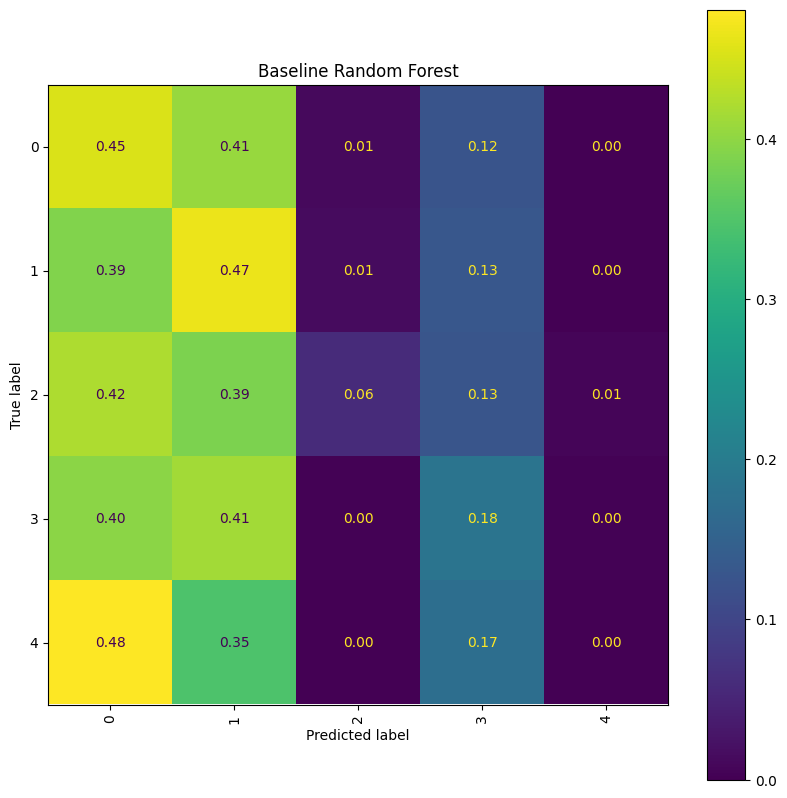

In [35]:
cm = confusion_matrix(y_test, y_pred_base, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Baseline Random Forest")
plt.show()

#### Visualizations

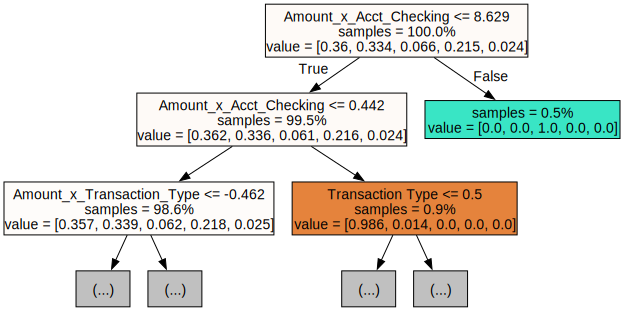

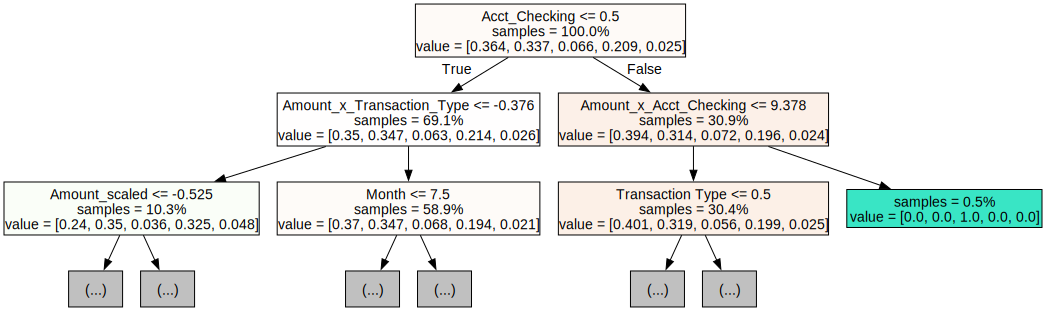

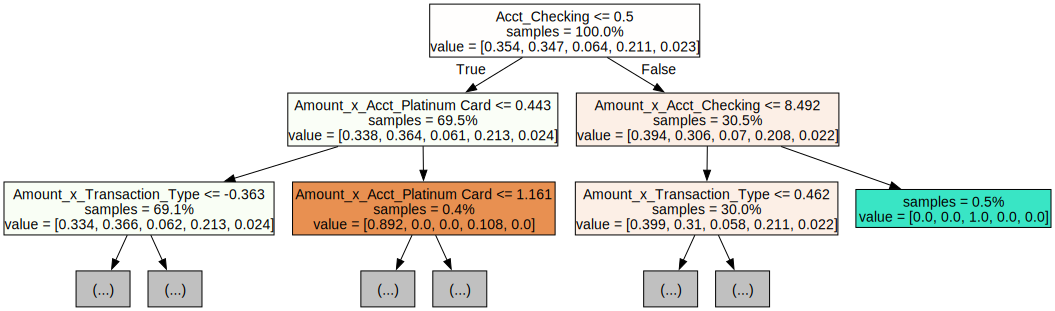

In [36]:
# result visualizations (tree visualization)
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# first 3 decision trees
for i in range(3):
    tree = base_rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

### Balanced Model

In [37]:
balanced_cv_acc = []
balanced_cv_f1 = []

for depth in depth_values:
    print(f"Training balanced RF with max_depth = {depth}")

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    acc_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring="accuracy")
    f1_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring="f1_weighted")

    balanced_cv_acc.append(acc_scores.mean())
    balanced_cv_f1.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

Training balanced RF with max_depth = None
CV Acc: 0.3556, CV F1: 0.3433
--------------------------------------------------
Training balanced RF with max_depth = 10
CV Acc: 0.3253, CV F1: 0.3310
--------------------------------------------------
Training balanced RF with max_depth = 20
CV Acc: 0.3569, CV F1: 0.3452
--------------------------------------------------
Training balanced RF with max_depth = 30
CV Acc: 0.3567, CV F1: 0.3444
--------------------------------------------------


In [38]:
best_bal_index = np.argmax(balanced_cv_f1)
best_bal_depth = depth_values[best_bal_index]

print("Best balanced depth:", best_bal_depth)

Best balanced depth: 20


#### Evaluation

In [39]:
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=best_bal_depth,
    class_weight="balanced",
    random_state=42
)

best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

print("Balanced Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Balanced Tuned Accuracy: 0.34921369102682703
              precision    recall  f1-score   support

           0       0.38      0.41      0.40       764
           1       0.37      0.42      0.39       745
           2       0.15      0.07      0.10       135
           3       0.28      0.25      0.26       466
           4       0.06      0.02      0.03        52

    accuracy                           0.35      2162
   macro avg       0.25      0.24      0.24      2162
weighted avg       0.33      0.35      0.34      2162



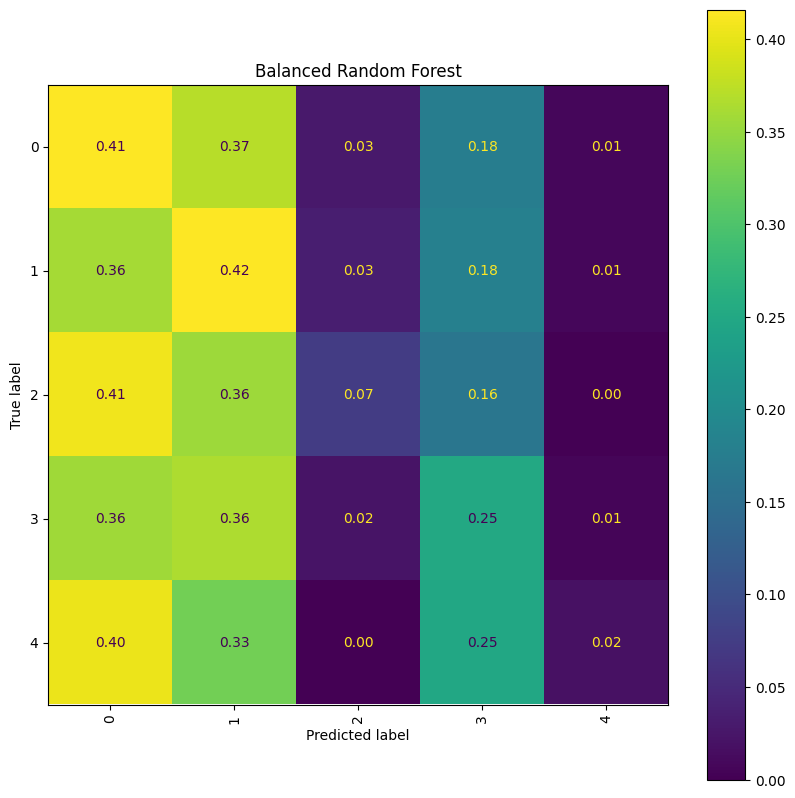

In [40]:
cm = confusion_matrix(y_test, y_pred_best, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Balanced Random Forest")
plt.show()